# 2. Phase field optimization

Using the extracted point-based signals as input, we optimize the phase field by minimizing a combined loss function,
\begin{equation}
\mathcal{L} 
= \lambda_\mathrm{data} \mathcal{L}_\mathrm{data} 
+ \lambda_\mathrm{B.C.} \mathcal{L}_\mathrm{B.C.} 
+ \lambda_\mathrm{physics} \mathcal{L}_\mathrm{physics} 
+ \lambda_\mathrm{smooth} \mathcal{L}_\mathrm{smooth}.
\end{equation}
Here, $\mathcal{L}_\mathrm{data}$, $\mathcal{L}_\mathrm{B.C.}$, $\mathcal{L}_\mathrm{physics}$, and $\mathcal{L}_\mathrm{smooth}$ denote the data loss, boundary condition loss, physics loss, and smoothing loss, respectively.

The optimization is performed in three stages. In the first stage, only the data and boundary condition losses are used, while the physics and smoothing losses are disabled. In the second stage, the physics loss is activated, but the smoothing loss remains inactive. In the final stage, all loss terms are included.

After the second stage, collocation points for the smoothing loss are sampled from the zero level set of the optimized phase field, and are subsequently used as input for the third stage of optimization.

##### Input:
- `example/data/pts_e_{shape}.npz` (edge/bulk signals)
- `example/data/pts_s_{shape}.npz` (inside/outside signals)
- `example/data/pts_p_{shape}.npz` (physics collocation points)

##### Intermediate:
- `example/data/pts_c_{shape}.npz` (smoothing collocation points)

##### Output:
- `example/output/stage***/checkpoint***` (phase field log data)
- `example/output/stage***/result.png`    (result summary)

In [1]:
import sys
import os
import numpy as np
from pathlib import Path

#### Add program source to sys.path ####
project_root = Path().resolve()
sys.path.append(str(project_root / "../src"))

#### Three-stage calculation of the phase field

In [ ]:
from pinn.run import run_sim, sample_curv_points

#### Parameters ####
data_path = "../example/data"
output_dir = "../example/output"
shape = "bud-11"
lambda_1 = 100000   # data loss
lambda_2 = 100000   # B.C. loss
lambda_3 = 1        # physics loss
lambda_4 = 10       # smoothing loss
num_steps = 10000
save_interval = 1000

#### Stage 1: lambda_3 = 0, lambda_4 = 0 ####
run_sim(
    data_path=data_path,
    output_dir=output_dir,
    shape=shape,
    sdf_pretrain="uniform",
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    lambda_3=0, 
    lambda_4=0,
    num_steps=num_steps,
    save_interval=save_interval,
    stage = 0,
)

#### Stage 2: lambda_4 = 0 ####
run_sim(
    data_path=data_path,
    output_dir=output_dir,
    shape=shape,
    sdf_pretrain="checkpoint",
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    lambda_3=lambda_3,
    lambda_4=0,
    num_steps=num_steps,
    save_interval=save_interval,
    stage = 1,
)

#### Sample smoothing loss collocation points ####
sample_curv_points(
    data_path=data_path,
    output_dir=output_dir,
    shape=shape,
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    lambda_3=lambda_3,
    num_curv = 5000,
    step = num_steps,
)

#### Stage 3 ####
run_sim(
    data_path=data_path,
    output_dir=output_dir,
    shape=shape,
    sdf_pretrain="checkpoint",
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    lambda_3=lambda_3,
    lambda_4=lambda_4,
    num_steps=num_steps,
    save_interval=save_interval,
    stage = 2,
)


#### Visualization of the final phase field

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/example/output/stage2_100000_100000_1_10/checkpoint_10000


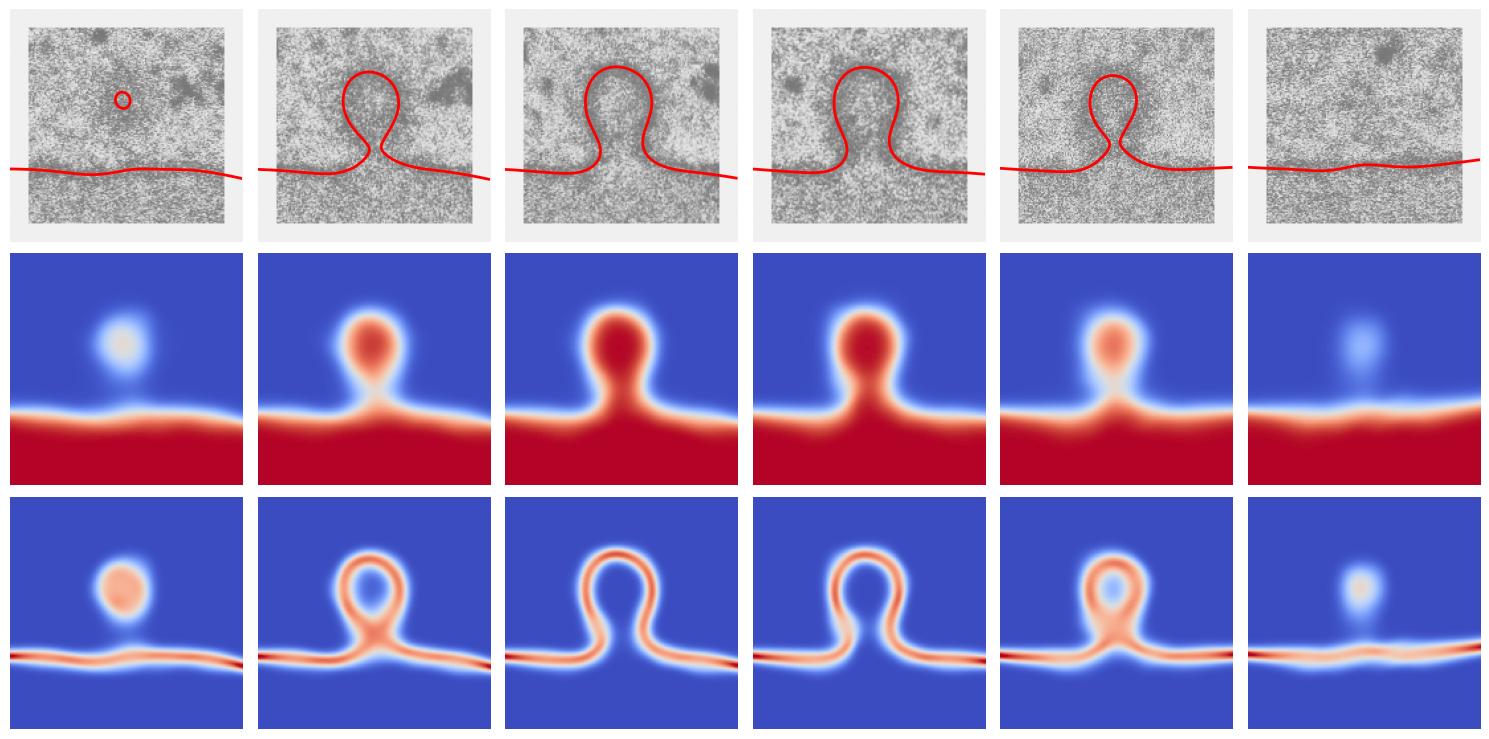

In [15]:
from pinn.plot import visualize_cryoET_with_contours, visualize_phase
import tifffile as tiff
import matplotlib.pyplot as plt
from flax.training import checkpoints

# ==== Parameters =====
lambda_1 = 100000
lambda_2 = 100000
lambda_3 = 1
lambda_4 = 10
step = 10000
stage = 2
axis = "x"
shape = "bud-11"
slices = range(60, 120, 10)
expand_xy = None

# ==== Load checkpoint data =====
checkpoint_dir = f"../example/output/stage{stage}_{lambda_1}_{lambda_2}_{lambda_3}_{lambda_4}"
checkpoint_path = os.path.abspath(f"{checkpoint_dir}/checkpoint_{step}")
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
print(checkpoint_path)

# ===== Load cryoET data =====
tif_file_path = f"../example/data/{shape}.tif"
cryoET_data = tiff.imread(tif_file_path)
cryoET_data = 1 - cryoET_data
grid_size = cryoET_data.shape[0]

# ==== Plot output =====
n = len(slices)
fig, axes = plt.subplots(3, n, figsize=(2.5*n, 2.5*3))

# --- row 1: cryoET + contour ---
for ax, slice_index in zip(axes[0], slices):
    visualize_cryoET_with_contours(
        ax, step, checkpoint_data, cryoET_data, grid_size=grid_size, 
        slice_index=slice_index, axis=axis, no_label=True, expand_xy=expand_xy,
    )

# --- row 2: phi ---
for ax, slice_index in zip(axes[1], slices):
    visualize_phase(
        ax, epsilon=0.05, checkpoint=checkpoint_data, component="phi", grid_size=grid_size,
        slice_index=slice_index, axis=axis, no_label=True, vmin=-1, vmax=1, expand_xy=expand_xy,
    )

# --- row 3: tension ---
for ax, slice_index in zip(axes[2], slices):
    visualize_phase(
        ax, epsilon=0.05, checkpoint=checkpoint_data, component="tension", grid_size=grid_size,
        slice_index=slice_index, axis=axis, no_label=True, vmin=0.0, vmax=1.0, expand_xy=expand_xy,
    )

plt.tight_layout()
plt.show()